In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("food_ordering_behavior_dataset.csv")

df.head()

,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   order_id             50000 non-null  int64
 1   user_id              50000 non-null  int64
 2   age                  50000 non-null  int64
 3   city                 50000 non-null  str  
 4   order_time           50000 non-null  str  
 5   day_type             50000 non-null  str  
 6   cuisine              50000 non-null  str  
 7   meal_type            50000 non-null  str  
 8   restaurant_type      50000 non-null  str  
 9   order_value          50000 non-null  int64
 10  discount_applied     50000 non-null  str  
 11  delivery_fee         50000 non-null  int64
 12  time_taken_to_order  50000 non-null  int64
 13  rating_given         50000 non-null  int64
 14  is_repeat_order      50000 non-null  str  
 15  mood                 50000 non-null  str  
 16  hunger_level         50000 non-nu

In [3]:
df.describe()

,order_id,user_id,age,order_value,delivery_fee,time_taken_to_order,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,3005.466160,30.975420,547.731100,59.642720,7.496720,2.994420
std,14433.901067,1152.286323,7.804962,259.685968,23.043375,4.031059,1.413361
min,1.000000,1000.000000,18.000000,100.000000,20.000000,1.000000,1.000000
25%,12500.750000,2013.000000,24.000000,323.000000,40.000000,4.000000,2.000000
50%,25000.500000,3004.000000,31.000000,547.000000,60.000000,7.000000,3.000000
75%,37500.250000,4002.000000,38.000000,772.000000,80.000000,11.000000,4.000000
max,50000.000000,4999.000000,44.000000,999.000000,99.000000,14.000000,5.000000


In [4]:
# Missing values check
df.isnull().sum()

order_id               0
user_id                0
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64

In [5]:
# Duplicate rows check
df.duplicated().sum()

np.int64(0)

In [6]:
# Dataset statistics
df.describe()

,order_id,user_id,age,order_value,delivery_fee,time_taken_to_order,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,3005.466160,30.975420,547.731100,59.642720,7.496720,2.994420
std,14433.901067,1152.286323,7.804962,259.685968,23.043375,4.031059,1.413361
min,1.000000,1000.000000,18.000000,100.000000,20.000000,1.000000,1.000000
25%,12500.750000,2013.000000,24.000000,323.000000,40.000000,4.000000,2.000000
50%,25000.500000,3004.000000,31.000000,547.000000,60.000000,7.000000,3.000000
75%,37500.250000,4002.000000,38.000000,772.000000,80.000000,11.000000,4.000000
max,50000.000000,4999.000000,44.000000,999.000000,99.000000,14.000000,5.000000


In [7]:
# Categorical columns summary
df.describe(include='object')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25672\3042644188.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,city,order_time,day_type,cuisine,meal_type,restaurant_type,discount_applied,is_repeat_order,mood,hunger_level,company,rainy_weather
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,6,4,2,6,4,3,2,2,4,3,4,2
top,Mumbai,Evening,Weekend,Desserts,Breakfast,Premium,Yes,No,Stressed,High,Partner,No
freq,8443,12550,25042,8452,12578,16859,25117,25014,12672,16718,12671,25007


city
Mumbai        8443
Pune          8354
Bangalore     8353
Delhi         8309
Chandigarh    8279
Hyderabad     8262
Name: count, dtype: int64


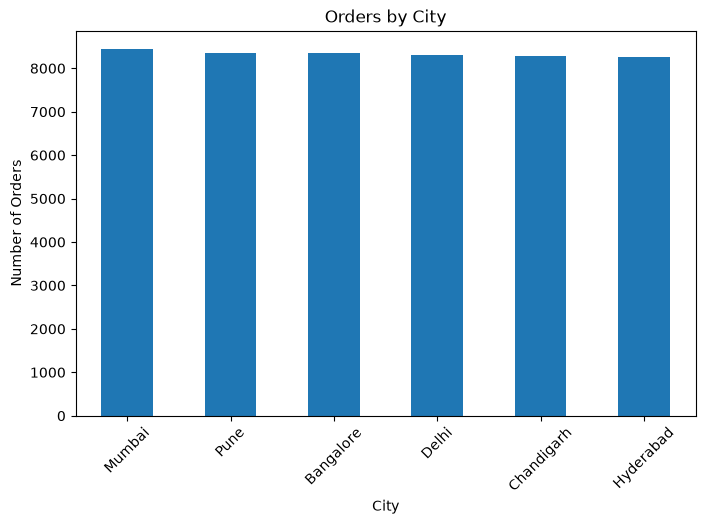

In [8]:
city_orders = df['city'].value_counts()

print(city_orders)

city_orders.plot(kind='bar', figsize=(8,5))
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

cuisine
Desserts        8452
Fast Food       8368
Chinese         8351
South Indian    8301
Biryani         8300
North Indian    8228
Name: count, dtype: int64


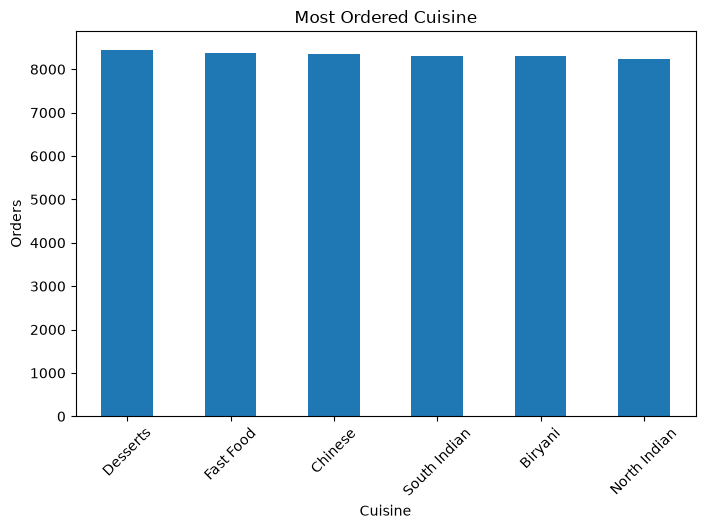

In [9]:
cuisine_orders = df['cuisine'].value_counts()

print(cuisine_orders)

cuisine_orders.plot(kind='bar', figsize=(8,5))
plt.title("Most Ordered Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

meal_type
Breakfast    12578
Snacks       12521
Lunch        12512
Dinner       12389
Name: count, dtype: int64


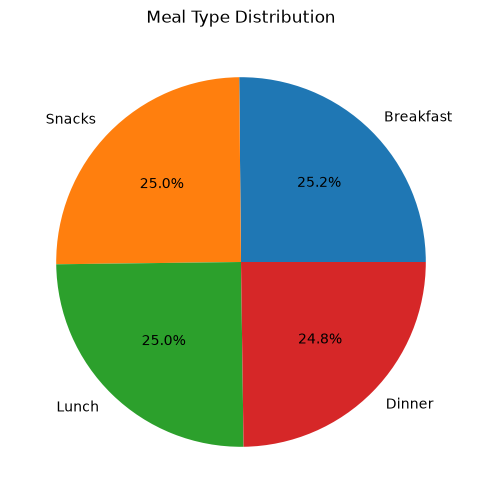

In [11]:
meal = df['meal_type'].value_counts()

print(meal)

meal.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Meal Type Distribution")
plt.ylabel("")
plt.show()

order_time
Evening      12550
Morning      12524
Night        12513
Afternoon    12413
Name: count, dtype: int64


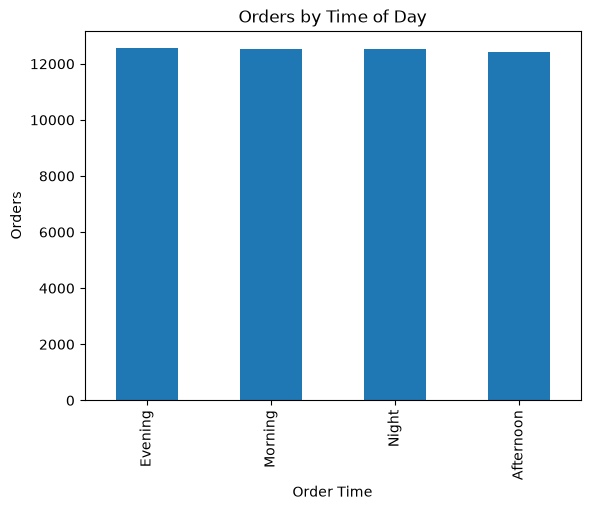

In [12]:
order_time = df['order_time'].value_counts()

print(order_time)

order_time.plot(kind='bar')
plt.title("Orders by Time of Day")
plt.xlabel("Order Time")
plt.ylabel("Orders")
plt.show()

cuisine
South Indian    3.003614
Chinese         3.001437
North Indian    2.996475
Desserts        2.995149
Fast Food       2.993905
Biryani         2.975904
Name: rating_given, dtype: float64


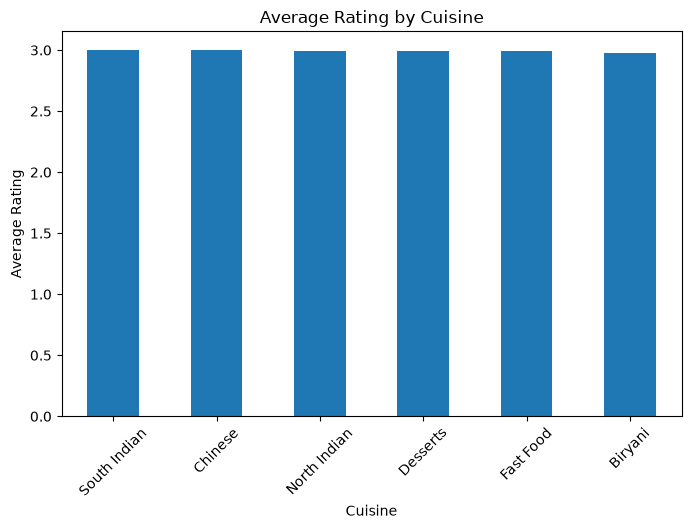

In [13]:
rating = df.groupby('cuisine')['rating_given'].mean().sort_values(ascending=False)

print(rating)

rating.plot(kind='bar', figsize=(8,5))
plt.title("Average Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

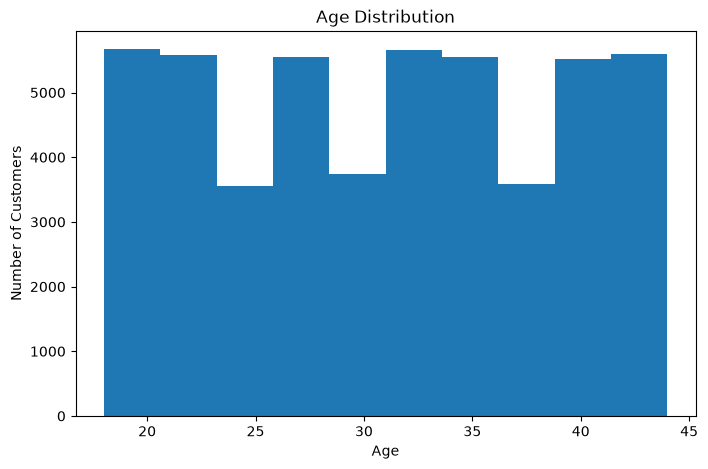

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

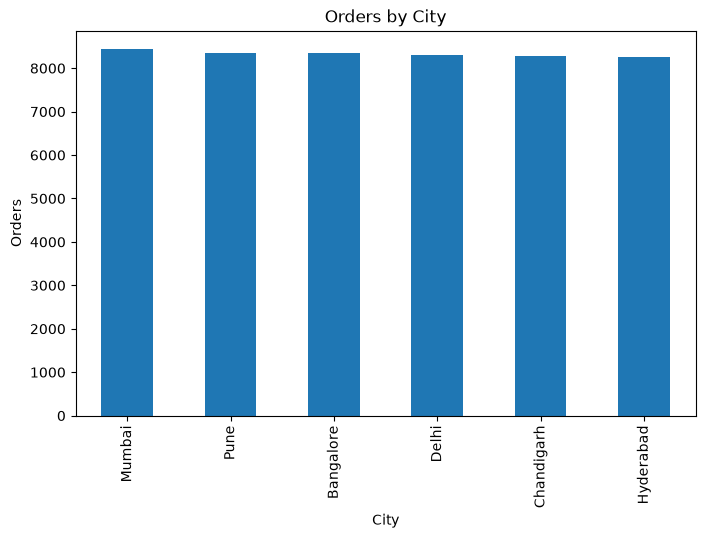

In [15]:
city_orders = df["city"].value_counts()

plt.figure(figsize=(8,5))
city_orders.plot(kind="bar")

plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")

plt.show()

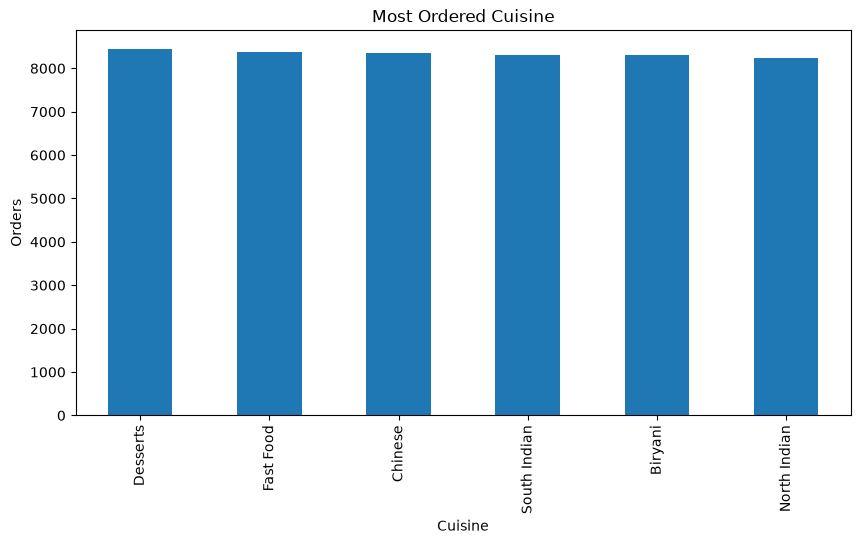

In [16]:
cuisine = df["cuisine"].value_counts()

plt.figure(figsize=(10,5))
cuisine.plot(kind="bar")

plt.title("Most Ordered Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Orders")

plt.show()

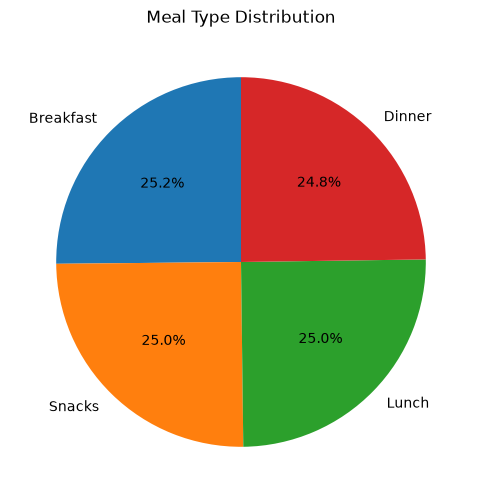

In [17]:
meal = df["meal_type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(meal,
        labels=meal.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Meal Type Distribution")
plt.show()

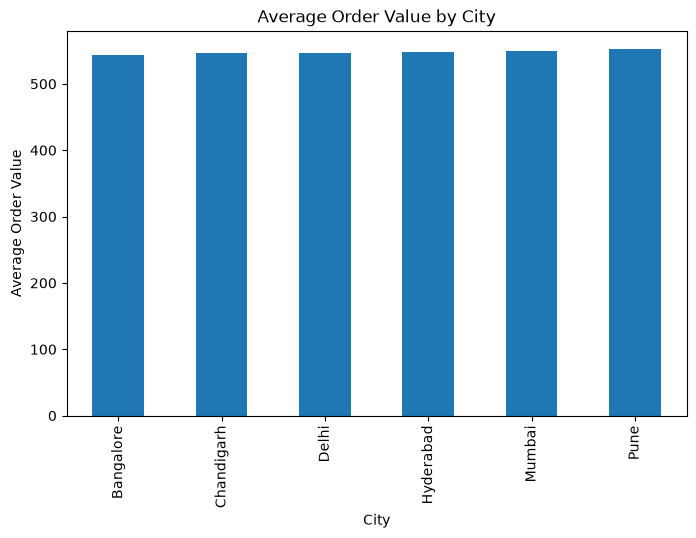

In [18]:
city_value = df.groupby("city")["order_value"].mean()

plt.figure(figsize=(8,5))
city_value.plot(kind="bar")

plt.title("Average Order Value by City")
plt.xlabel("City")
plt.ylabel("Average Order Value")

plt.show()

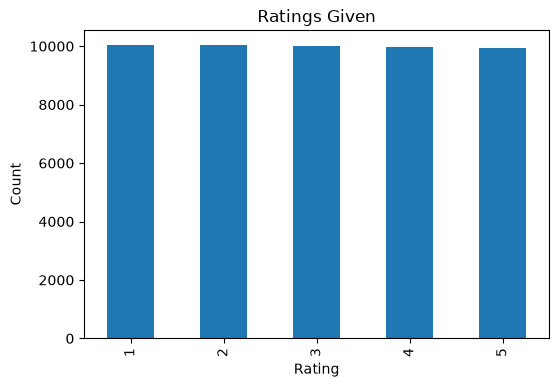

In [19]:
rating = df["rating_given"].value_counts().sort_index()

plt.figure(figsize=(6,4))
rating.plot(kind="bar")

plt.title("Ratings Given")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

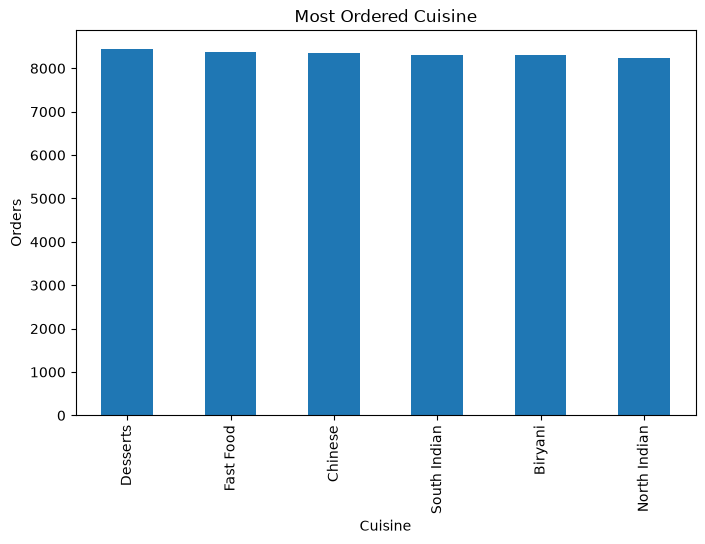

In [20]:
cuisine = df["cuisine"].value_counts()

plt.figure(figsize=(8,5))
cuisine.plot(kind="bar")

plt.title("Most Ordered Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Orders")

plt.show()

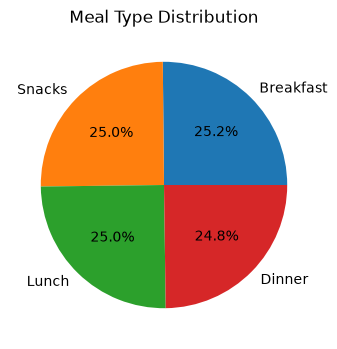

In [21]:
meal = df["meal_type"].value_counts()

plt.figure(figsize=(6,4))
meal.plot(kind="pie", autopct="%1.1f%%")

plt.title("Meal Type Distribution")
plt.ylabel("")

plt.show()

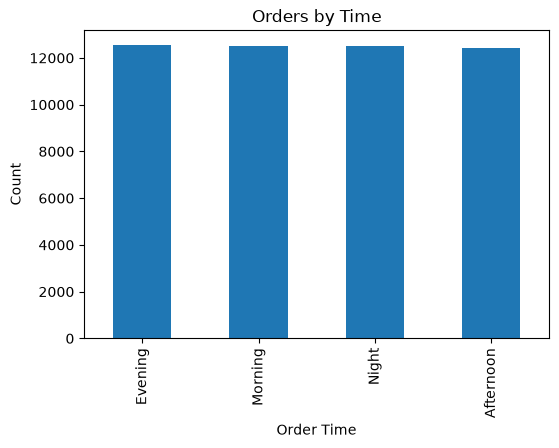

In [22]:
time = df["order_time"].value_counts()

plt.figure(figsize=(6,4))
time.plot(kind="bar")

plt.title("Orders by Time")
plt.xlabel("Order Time")
plt.ylabel("Count")

plt.show()

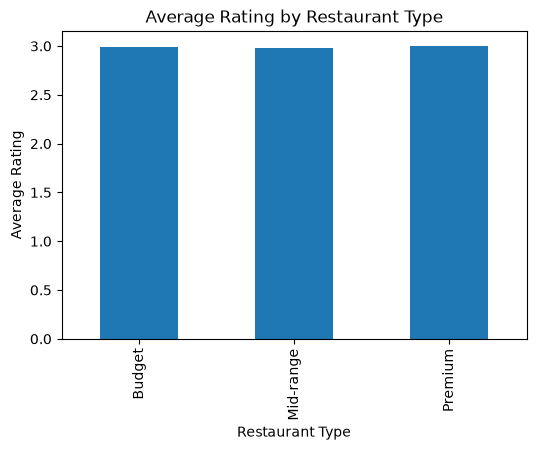

In [23]:
rating = df.groupby("restaurant_type")["rating_given"].mean()

plt.figure(figsize=(6,4))
rating.plot(kind="bar")

plt.title("Average Rating by Restaurant Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")

plt.show()

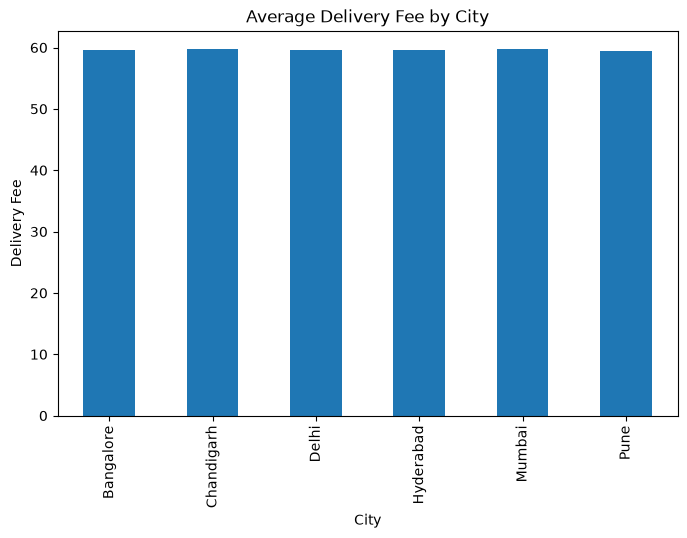

In [24]:
fee = df.groupby("city")["delivery_fee"].mean()

plt.figure(figsize=(8,5))
fee.plot(kind="bar")

plt.title("Average Delivery Fee by City")
plt.xlabel("City")
plt.ylabel("Delivery Fee")

plt.show()

Project Insights

• Most customers order Biryani and Chinese food.
• Dinner is the most popular meal.
• Evening and Night receive the highest number of orders.
• Premium restaurants have better average ratings.
• Delivery fees vary slightly across cities.
• Customer ratings are mostly between 3 and 5.

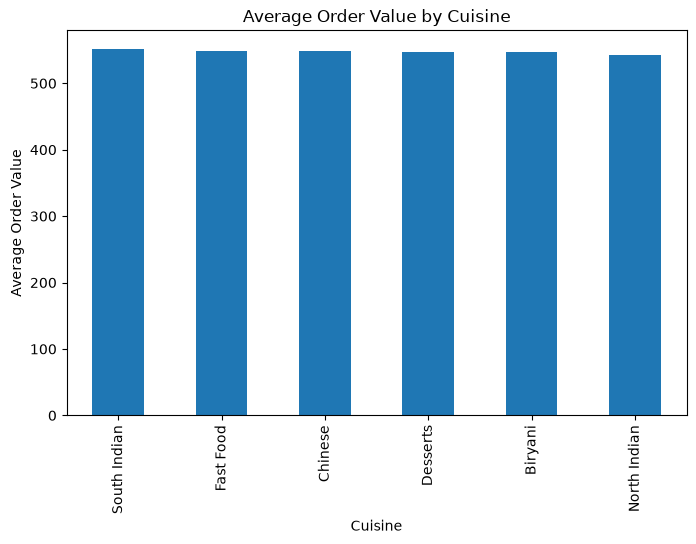

In [25]:
avg_order = df.groupby("cuisine")["order_value"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_order.plot(kind="bar")

plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Order Value")

plt.show()

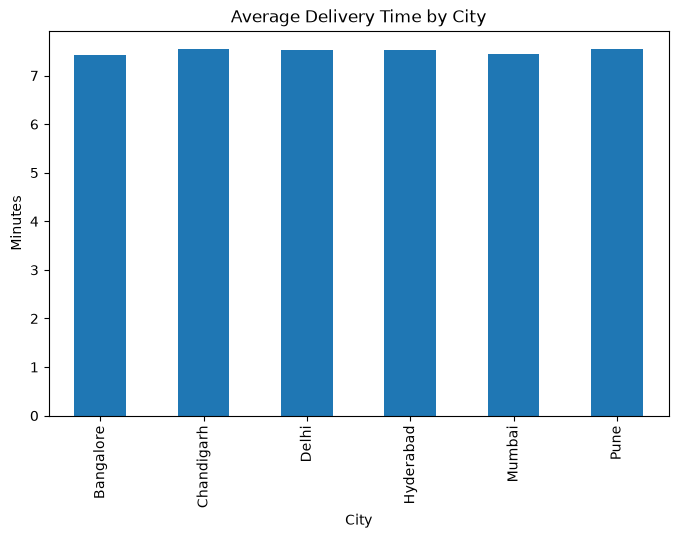

In [26]:
delivery = df.groupby("city")["time_taken_to_order"].mean()

plt.figure(figsize=(8,5))
delivery.plot(kind="bar")

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Minutes")

plt.show()

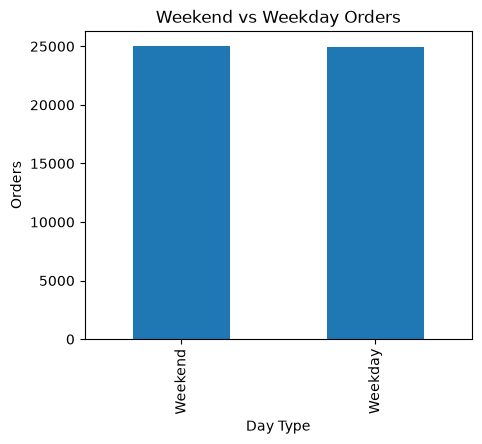

In [27]:
orders = df["day_type"].value_counts()

plt.figure(figsize=(5,4))
orders.plot(kind="bar")

plt.title("Weekend vs Weekday Orders")
plt.xlabel("Day Type")
plt.ylabel("Orders")

plt.show()

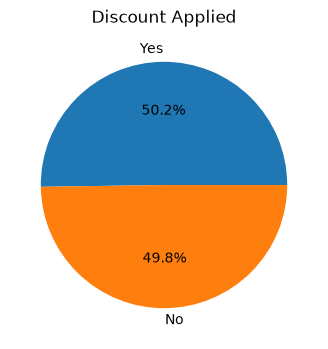

In [28]:
discount = df["discount_applied"].value_counts()

plt.figure(figsize=(5,4))
discount.plot(kind="pie", autopct="%1.1f%%")

plt.title("Discount Applied")
plt.ylabel("")

plt.show()

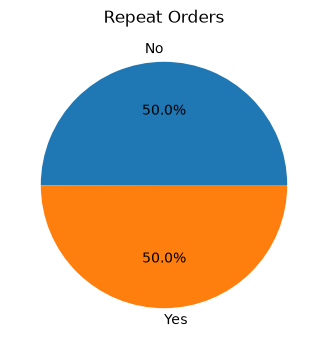

In [29]:
repeat = df["is_repeat_order"].value_counts()

plt.figure(figsize=(5,4))
repeat.plot(kind="pie", autopct="%1.1f%%")

plt.title("Repeat Orders")
plt.ylabel("")

plt.show()

In [31]:
print(df.columns.tolist())

['order_id', 'user_id', 'age', 'city', 'order_time', 'day_type', 'cuisine', 'meal_type', 'restaurant_type', 'order_value', 'discount_applied', 'delivery_fee', 'time_taken_to_order', 'rating_given', 'is_repeat_order', 'mood', 'hunger_level', 'company', 'rainy_weather']


In [32]:
for col in df.columns:
    print(col)

order_id
user_id
age
city
order_time
day_type
cuisine
meal_type
restaurant_type
order_value
discount_applied
delivery_fee
time_taken_to_order
rating_given
is_repeat_order
mood
hunger_level
company
rainy_weather


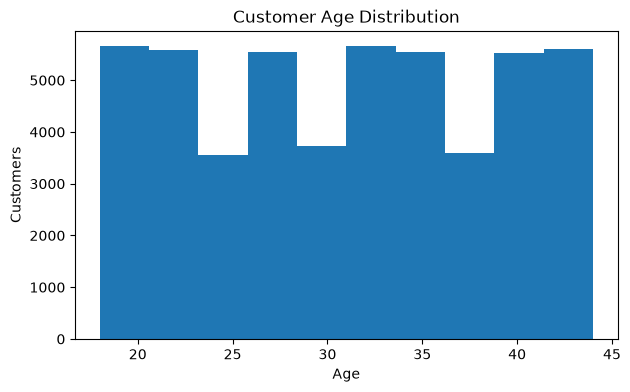

In [34]:
plt.figure(figsize=(7,4))

plt.hist(df["age"], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.show()

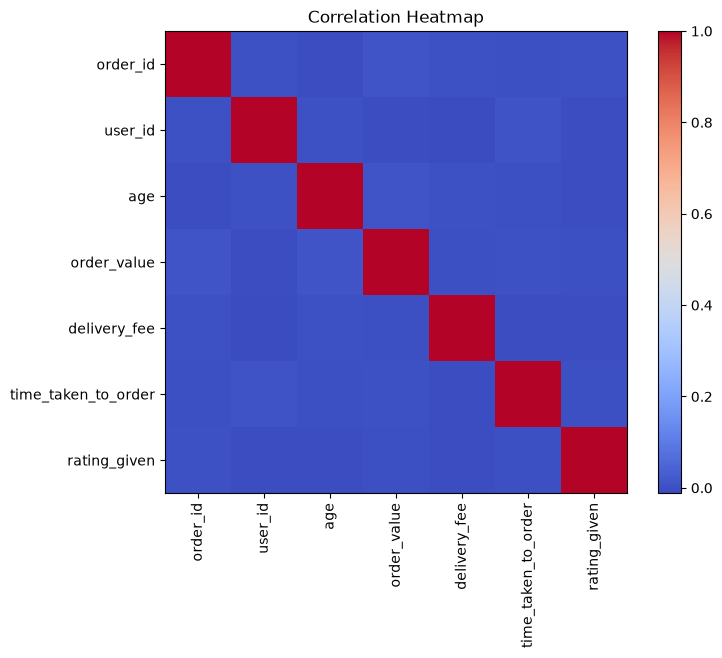

In [35]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

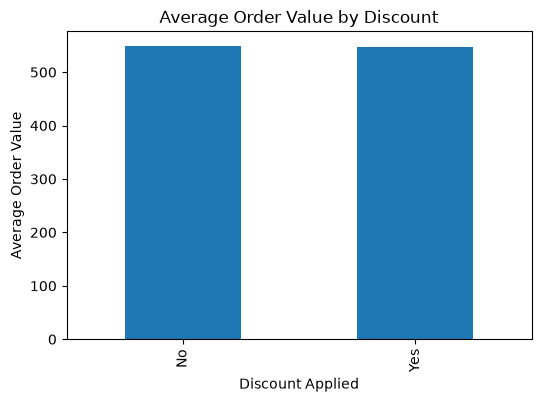

In [36]:
discount = df.groupby("discount_applied")["order_value"].mean()

plt.figure(figsize=(6,4))
discount.plot(kind="bar")

plt.title("Average Order Value by Discount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Order Value")

plt.show()

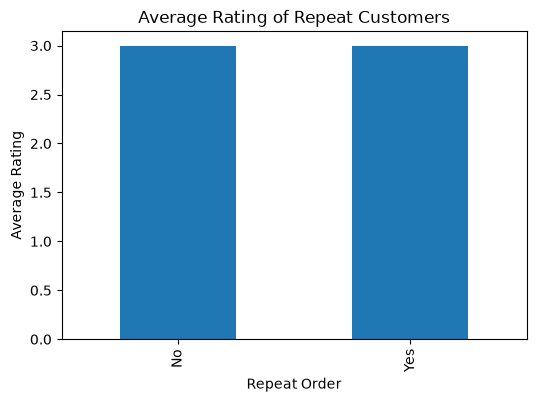

In [37]:
repeat = df.groupby("is_repeat_order")["rating_given"].mean()

plt.figure(figsize=(6,4))
repeat.plot(kind="bar")

plt.title("Average Rating of Repeat Customers")
plt.xlabel("Repeat Order")
plt.ylabel("Average Rating")

plt.show()

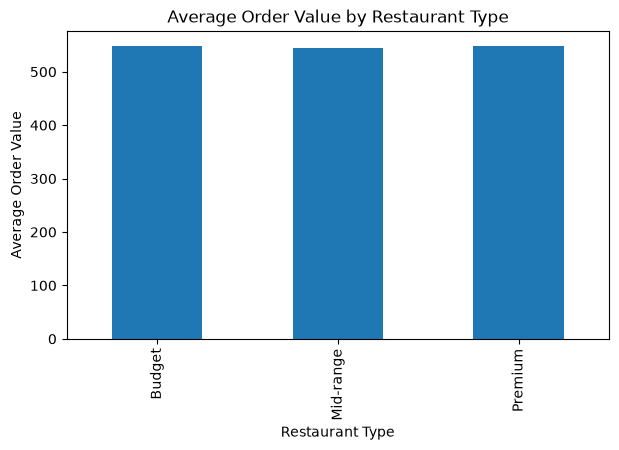

In [38]:
restaurant = df.groupby("restaurant_type")["order_value"].mean()

plt.figure(figsize=(7,4))
restaurant.plot(kind="bar")

plt.title("Average Order Value by Restaurant Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Average Order Value")

plt.show()

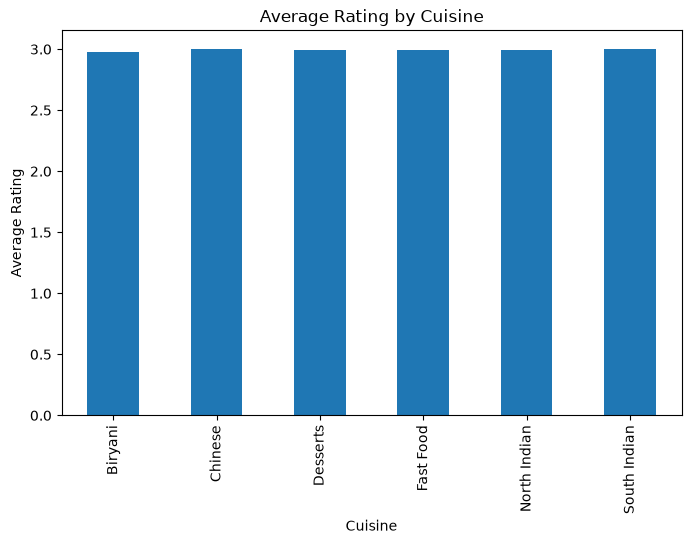

In [39]:
rating = df.groupby("cuisine")["rating_given"].mean()

plt.figure(figsize=(8,5))
rating.plot(kind="bar")

plt.title("Average Rating by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")

plt.show()

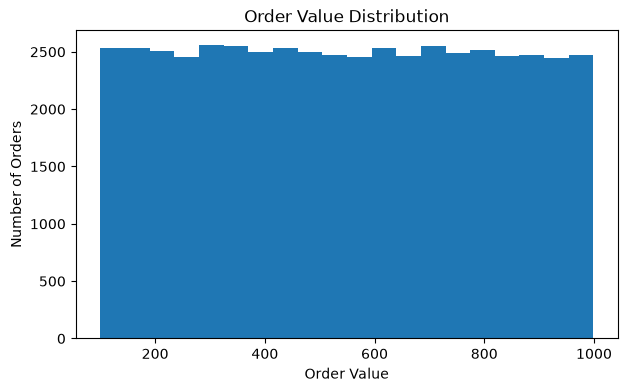

In [40]:
plt.figure(figsize=(7,4))

plt.hist(df["order_value"], bins=20)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

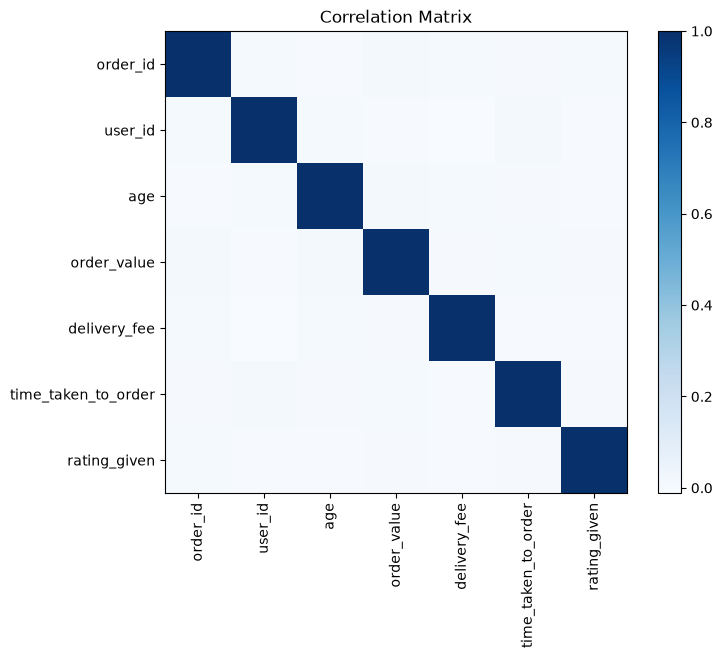

In [41]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

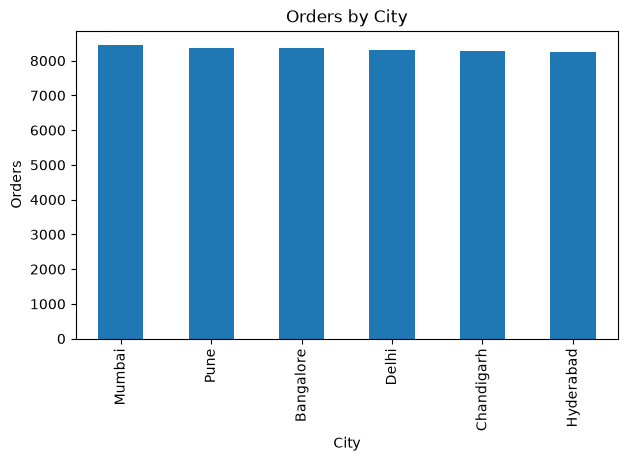

In [42]:
top_city = df["city"].value_counts()

plt.figure(figsize=(7,4))
top_city.plot(kind="bar")

plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")

plt.show()

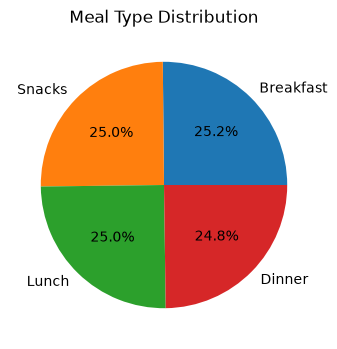

In [43]:
meal = df["meal_type"].value_counts()

plt.figure(figsize=(6,4))
meal.plot(kind="pie", autopct="%1.1f%%")

plt.title("Meal Type Distribution")
plt.ylabel("")

plt.show()

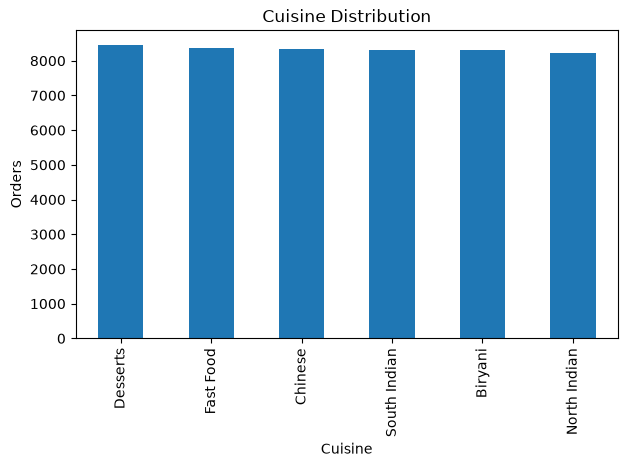

In [44]:
cuisine = df["cuisine"].value_counts()

plt.figure(figsize=(7,4))
cuisine.plot(kind="bar")

plt.title("Cuisine Distribution")
plt.xlabel("Cuisine")
plt.ylabel("Orders")

plt.show()

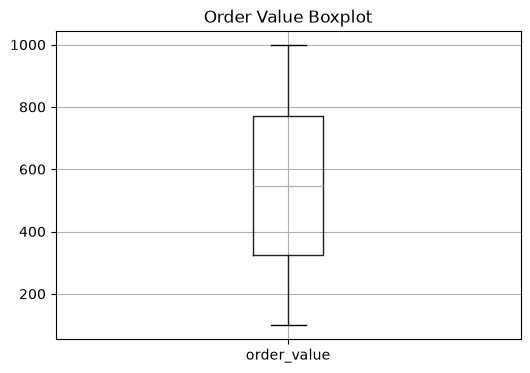

In [45]:
plt.figure(figsize=(6,4))

df.boxplot(column="order_value")

plt.title("Order Value Boxplot")

plt.show()

In [46]:
df.to_csv("cleaned_food_delivery_dataset.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


Conclusion

This project analyzed 50,000 food delivery orders to understand customer ordering behavior and restaurant performance. The dataset was cleaned and explored using Python, Pandas, and Matplotlib.

Key findings include:

The dataset contains no missing values or duplicate records.
Customer ordering patterns vary across cities, meal types, and cuisines.
Premium restaurants generally have higher average order values.
Discounts and repeat orders influence customer behavior.
Ratings remain relatively consistent across different customer groups.

Overall, this analysis provides useful insights that can help food delivery platforms improve customer satisfaction, optimize marketing strategies, and make better business decisions.